## Imports

In [2]:
# IMPORTS
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mne.time_frequency import psd_array_welch
from mne.preprocessing import ICA
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors
from typing import List, Optional, Tuple, Dict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10
mne.viz.set_browser_backend('matplotlib')

print("Libraries imported successfully!")
print(f"MNE version: {mne.__version__}")

Using matplotlib as 2D backend.
Libraries imported successfully!
MNE version: 1.10.2


## Utility Functions

In [3]:
def load_eeg_data(patient: str, dbs_freq: int, base_path: str) -> tuple:
    """Load EEG data based on patient ID, DBS frequency, and sleep state."""
    file_path_sleep = f"{base_path}/{patient}/{patient}SLEEP{dbs_freq}.EDF"
    file_path_awake = f"{base_path}/{patient}/{patient}AWAKE{dbs_freq}.EDF"
    raw_sleep = mne.io.read_raw_edf(file_path_sleep, preload=True, verbose=False)
    raw_awake = mne.io.read_raw_edf(file_path_awake, preload=True, verbose=False)
    return raw_sleep, raw_awake

In [4]:
def print_eeg_info(raw, title="EEG DATA INFORMATION"):
    """Print comprehensive EEG information."""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)
    print(f"Channels: {raw.ch_names}")
    print(f"Number of channels: {len(raw.ch_names)}")
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"Duration: {raw.times[-1] / 60:.2f} minutes ({raw.times[-1] / 3600:.2f} hours)")
    print(f"Channel types: {set([raw.get_channel_types([ch])[0] for ch in raw.ch_names])}")
    print("="*80)

In [5]:
def set_custom_channel_types(raw_object):
    """Set channel types based on custom naming conventions."""
    eeg_10_20 = {
        'Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2',
        'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz', 'A1', 'A2'
    }
    ext_eeg = {'T1', 'T2', 'Fpz'}

    ch_types = {
        ch: 'eeg' if ch in eeg_10_20
        else 'eeg' if ch in ext_eeg
        else 'emg' if ch.startswith('EMG')
        else 'ecg' if ch.startswith('EKG')
        else 'eog' if ch.startswith('LOC') or ch.startswith('ROC')
        else 'misc'
        for ch in raw_object.ch_names
    }
    raw_object.set_channel_types(ch_types)
    print(f"✓ Channel types set for {len(raw_object.ch_names)} channels.")

In [6]:
def set_reference(raw_object, ref_channels: list or str = 'average'):
    """Set EEG reference."""
    raw_object.set_eeg_reference(ref_channels=ref_channels)
    print(f"✓ Reference set using channels: {ref_channels}")

In [7]:
def set_eeg_montage(raw_object, montage_name: str = 'standard_1020'):
    """Set EEG montage."""
    try:
        montage = mne.channels.make_standard_montage(montage_name)
        raw_object.set_montage(montage, on_missing='warn')
        print(f"✓ Montage '{montage_name}' set successfully!")
    except Exception as e:
        print(f"✗ Error setting montage: {e}")

In [8]:
def apply_frequency_filter(raw: mne.io.Raw, l_freq: Optional[float] = None,
                          h_freq: Optional[float] = None, powerline_freq: Optional[float] = None):
    """Apply bandpass and notch filters."""
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin')
    if powerline_freq is not None:
        raw.notch_filter(freqs=powerline_freq, fir_design='firwin')
    print(f"✓ Applied bandpass filter: {l_freq} - {h_freq} Hz")
    if powerline_freq:
        print(f"✓ Applied notch filter at {powerline_freq} Hz")

In [64]:
def DBS_harmonics_removal(raw: mne.io.Raw, dbs_freq: int, n_harmonics: int = 5, h_freq: Optional[float] = None):
    """Remove DBS harmonics using notch filters."""
    freqs_to_notch = np.arange(dbs_freq, h_freq, dbs_freq)[:n_harmonics]
    print(f"Notching frequencies: {freqs_to_notch} Hz")
    
    raw.notch_filter(
        freqs=freqs_to_notch,
        fir_design='firwin',
        trans_bandwidth=1.0
    )
    print(f"✓ Removed DBS harmonics up to {n_harmonics} harmonics at {dbs_freq} Hz intervals.")

### Visualization Functions

In [9]:
def plot_timeseries_custom(raw: mne.io.Raw, picks: Optional[List[str]] = None,
                           start: float = 0, duration: float = 10,
                           title: Optional[str] = None, figsize: Tuple[float, float] = (15, 10),
                           show: bool = True):
    """Plot time series with automatic EEG channel selection."""
    if picks is None:
        channel_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
        scalings = dict(eeg=50e-6)
    else:
        channel_picks = picks
        scalings = 'auto'
    
    if len(channel_picks) == 0:
        print("Warning: No channels found to plot.")
        return None
    
    if title is None:
        title = f"EEG Data ({len(channel_picks)} channels) from {start:.1f}s to {start + duration:.1f}s"
    
    fig = raw.plot(picks=channel_picks, start=start, duration=duration, title=title,
                   scalings=scalings, show=False, n_channels=len(channel_picks))
    fig.set_size_inches(figsize)
    plt.tight_layout()
    if show:
        plt.show()
    return fig

In [29]:
def plot_channel_comparison(raw1: mne.io.Raw, start1: float, raw2: mne.io.Raw, start2: float,
                            channel_name: str, duration: float = 5.0,
                            label1: str = 'Segment 1', label2: str = 'Segment 2',
                            figsize: Tuple[float, float] = (15, 8), y_limits: Optional[Tuple[float, float]] = None):
    """Compare two segments of a single channel."""
    if channel_name not in raw1.ch_names or channel_name not in raw2.ch_names:
        print(f"Error: Channel '{channel_name}' must exist in both Raw objects.")
        return None
    
    start_samp1, stop_samp1 = raw1.time_as_index([start1, start1 + duration])
    times1 = raw1.times[start_samp1:stop_samp1]
    data1 = raw1.get_data(picks=[channel_name], start=start_samp1, stop=stop_samp1)[0] * 1e6
    
    start_samp2, stop_samp2 = raw2.time_as_index([start2, start2 + duration])
    times2 = raw2.times[start_samp2:stop_samp2]
    data2 = raw2.get_data(picks=[channel_name], start=start_samp2, stop=stop_samp2)[0] * 1e6
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    fig.suptitle(f'Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')
    
    axes[0].plot(times1, data1, color='cornflowerblue', linewidth=0.8)
    axes[0].set_title(label1, fontsize=14)
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    if y_limits:
        axes[0].set_ylim(y_limits)
    
    axes[1].plot(times2, data2, color='indianred', linewidth=0.8)
    axes[1].set_title(label2, fontsize=14)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude (µV)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    if y_limits:
        axes[1].set_ylim(y_limits)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    return fig

In [11]:
def plot_psd_comparison(freqs_raw: np.ndarray, psd_raw: np.ndarray,
                       freqs_filt: np.ndarray, psd_filt: np.ndarray,
                       channel_name: str, artifact_freqs: Optional[List[float]] = None,
                       fmin: float = 0.0, fmax: float = 100.0,
                       figsize: Tuple[float, float] = (15, 10)):
    """Compare PSD before and after filtering."""
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle(f'PSD Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')
    
    axes[0].semilogy(freqs_raw, psd_raw, color='cornflowerblue', linewidth=1.5, label='Raw PSD')
    axes[0].set_title('Before Filtering', fontsize=14)
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    
    axes[1].semilogy(freqs_filt, psd_filt, color='forestgreen', linewidth=1.5, label='Filtered PSD')
    axes[1].set_title('After Filtering', fontsize=14)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power (µV²/Hz)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    
    colors = ['red', 'orange', 'purple', 'magenta', 'cyan', 'brown', 'pink', 'olive']
    if artifact_freqs:
        for i, freq in enumerate(artifact_freqs):
            label = f'{freq} Hz'
            axes[0].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                          linewidth=1.5, label=label, alpha=0.7)
            axes[1].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                          linewidth=1.5, alpha=0.5)
    
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')
    axes[1].set_xlim(fmin, fmax)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    return fig

In [12]:
def plot_band_power_topomaps(raw_object: mne.io.Raw, band_powers: Dict[str, np.ndarray],
                             suptitle: str = "Topographic Distribution of Band Powers",
                             save_path: Optional[str] = None):
    """Plot topographic distribution of frequency band powers."""
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        standard_channels = set(montage.ch_names)
        available_channels = [ch for ch in raw_object.ch_names if ch in standard_channels]
        
        if not available_channels:
            raise ValueError("No channels with standard 10-20 positions found.")
        
        raw_temp = raw_object.copy().pick(available_channels)
        raw_temp.set_montage(montage, on_missing='warn')
        
        ch_indices = [raw_object.ch_names.index(ch) for ch in available_channels]
        topo_band_powers = {band: powers[ch_indices] for band, powers in band_powers.items()}
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        for idx, (band_name, powers) in enumerate(topo_band_powers.items()):
            im, _ = mne.viz.plot_topomap(powers, raw_temp.info, axes=axes[idx], show=False,
                                        cmap='viridis', contours=6)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            cbar.set_label('Power (µV²)', rotation=270, labelpad=15)
        
        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])
        
        fig.suptitle(suptitle, fontsize=18, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
    except Exception as e:
        print(f"Could not create topographic plots: {e}")
        print("Creating bar plots instead...")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        for idx, (band_name, powers) in enumerate(band_powers.items()):
            axes[idx].bar(raw_object.ch_names, powers)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Band Power (µV²)')
            axes[idx].grid(True, axis='y', alpha=0.5)
            plt.setp(axes[idx].get_xticklabels(), rotation=90, ha='right')
        
        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])
        
        fig.suptitle(f"{suptitle} (Bar Plot)", fontsize=18, fontweight='bold')
        plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    return fig

### Frequency Analysis Functions

In [13]:
def get_psd(raw: mne.io.Raw, fmin: float = 0.5, fmax: float = 40.0,
           n_fft: int = 2048, n_overlap: int = 512, n_per_seg: int = 1024) -> tuple:
    """Compute Power Spectral Density using Welch's method."""
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    data, times = raw[picks, :]
    psds, freqs = psd_array_welch(data, sfreq=raw.info['sfreq'], fmin=fmin, fmax=fmax,
                                  n_fft=n_fft, n_overlap=n_overlap, n_per_seg=n_per_seg)
    return freqs, psds

In [14]:
def calculate_band_powers(psd: np.ndarray, freqs: np.ndarray, ch_names: List[str],
                         bands: Optional[Dict[str, Tuple[float, float]]] = None) -> pd.DataFrame:
    """Calculate power for frequency bands from PSD data."""
    if psd.shape[0] != len(ch_names):
        raise ValueError(f"PSD channels ({psd.shape[0]}) != channel names ({len(ch_names)})")
    
    if bands is None:
        bands = {
            'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
            'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30),
            'Gamma (30-40 Hz)': (30, 40)
        }
    
    band_powers = {}
    for band, (fmin, fmax) in bands.items():
        freq_indices = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        band_powers[band] = np.trapz(psd[:, freq_indices], dx=np.diff(freqs)[0], axis=1)
    
    band_power_df = pd.DataFrame(band_powers, index=ch_names)
    band_power_df.index.name = 'Channel'
    return band_power_df

In [15]:
def detect_bad_channels_by_variance(raw, z_threshold=3.0):
    """Detect bad channels using variance-based method."""
    data = raw.get_data(picks='eeg')
    variances = np.var(data, axis=1)
    z_scores = (variances - np.mean(variances)) / np.std(variances)
    bad_idx = np.where(np.abs(z_scores) > z_threshold)[0]
    eeg_channels = mne.pick_types(raw.info, eeg=True, exclude=[])
    return [raw.ch_names[eeg_channels[i]] for i in bad_idx]

## Pipeline Execution

### Data loading

In [16]:
# ## STEP 1: Load EDF Data

# %%
print("\n" + "="*80)
print("STEP 1: LOADING EDF DATA")
print("="*80)

# Configuration
patient = "XU"
dbs_freq = 7  # Hz
base_path = "../data"


STEP 1: LOADING EDF DATA


In [17]:
# Load data
raw_sleep, raw_awake = load_eeg_data(patient, dbs_freq, base_path)

In [18]:
print_eeg_info(raw_sleep, f"SLEEP DATA - {patient} {dbs_freq}Hz DBS")
print_eeg_info(raw_awake, f"AWAKE DATA - {patient} {dbs_freq}Hz DBS")


SLEEP DATA - XU 7Hz DBS
Channels: ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']
Number of channels: 46
Sampling frequency: 256.0 Hz
Duration: 10.63 minutes (0.18 hours)
Channel types: {'eeg'}

AWAKE DATA - XU 7Hz DBS
Channels: ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']
Number of channels: 46
Sampling frequency: 256.0 Hz
Duration: 9.47 minutes (0.16 hours)
Channel types: {'eeg'}


#### Raw data view

Plotting raw sleep data...


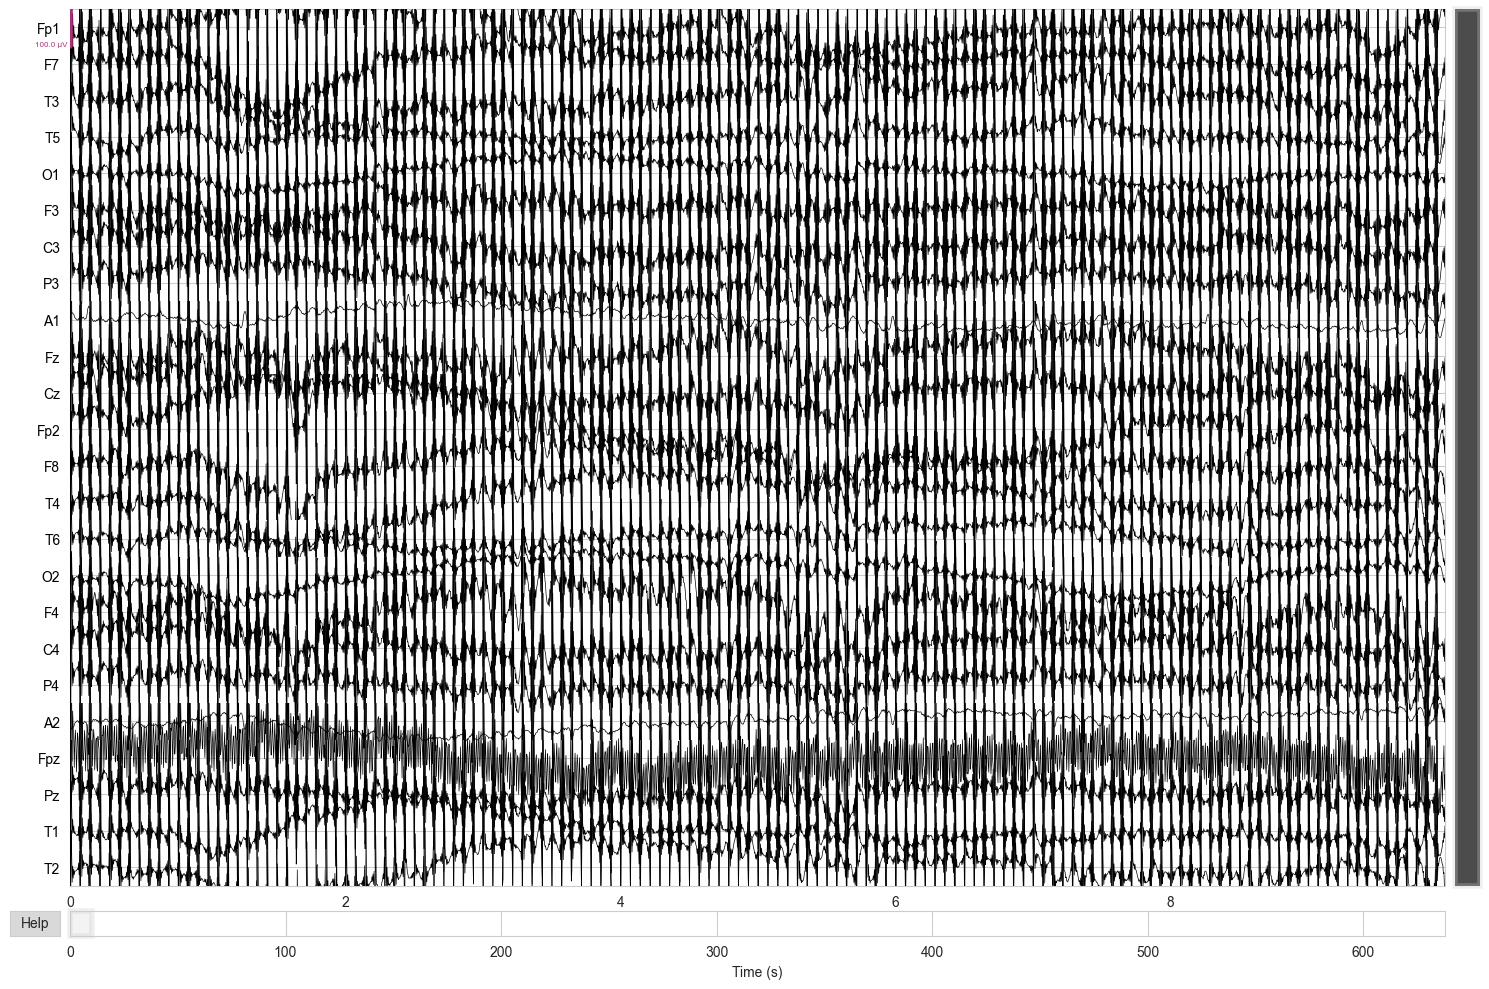

In [30]:
print("Plotting raw sleep data...")
fig = plot_timeseries_custom(raw_sleep, start=0, duration=10,
                             title=f"Step 1: Raw Sleep EEG - {patient} {dbs_freq}Hz DBS")

Plotting raw awake data...


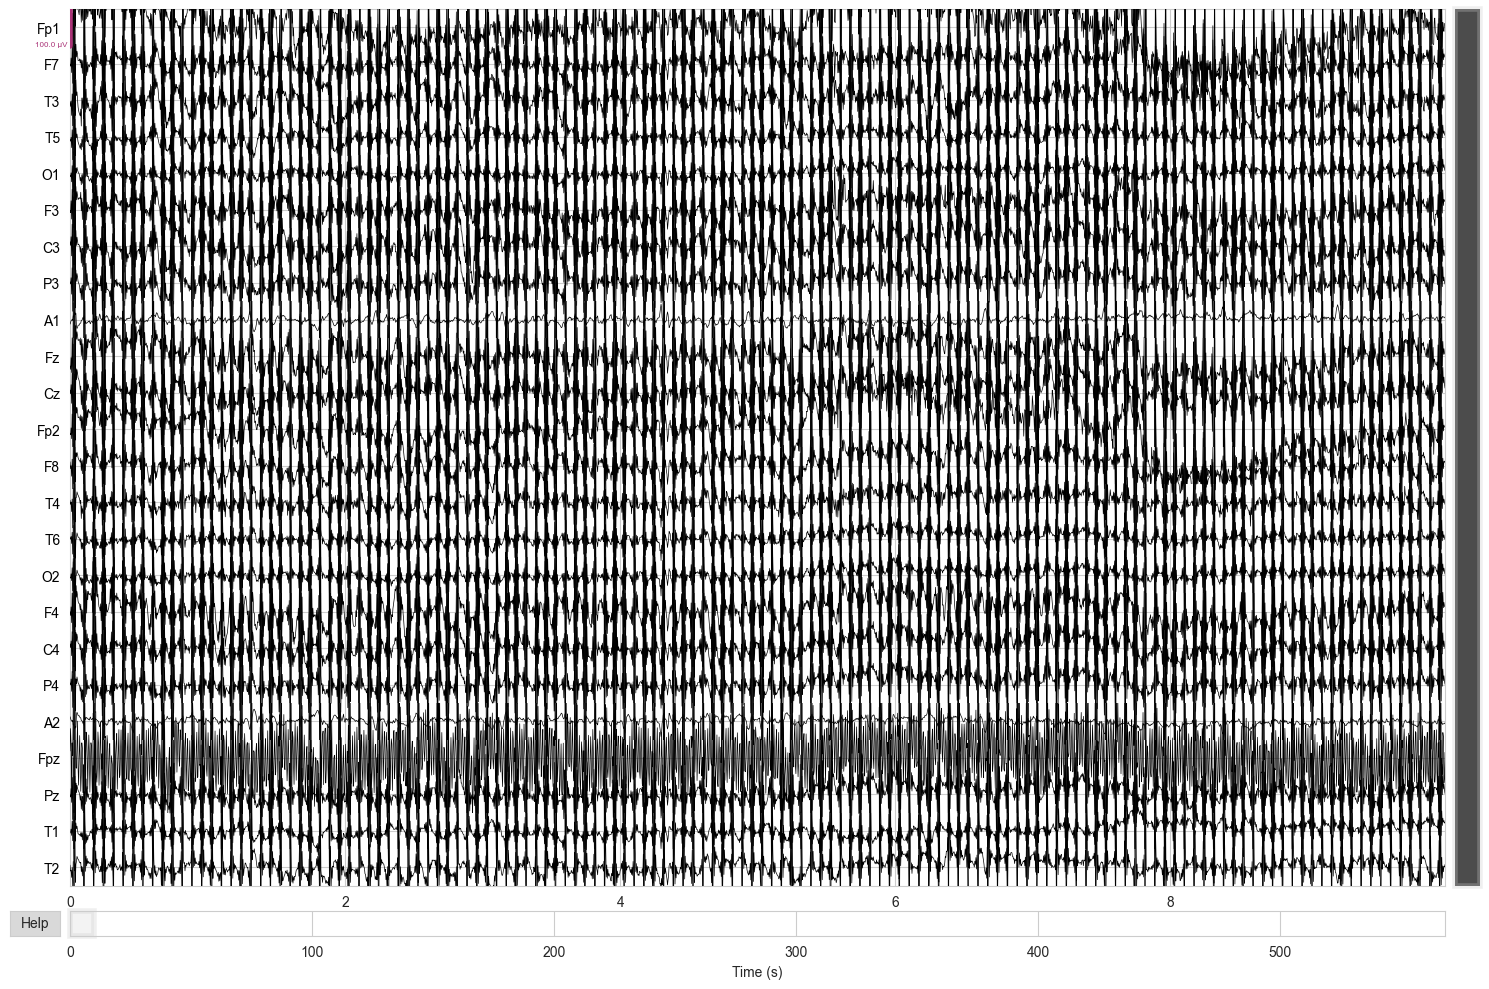

In [31]:
print("Plotting raw awake data...")
fig = plot_timeseries_custom(raw_awake, start=0, duration=10,
                             title=f"Step 1: Raw Awake EEG - {patient} {dbs_freq}Hz DBS")

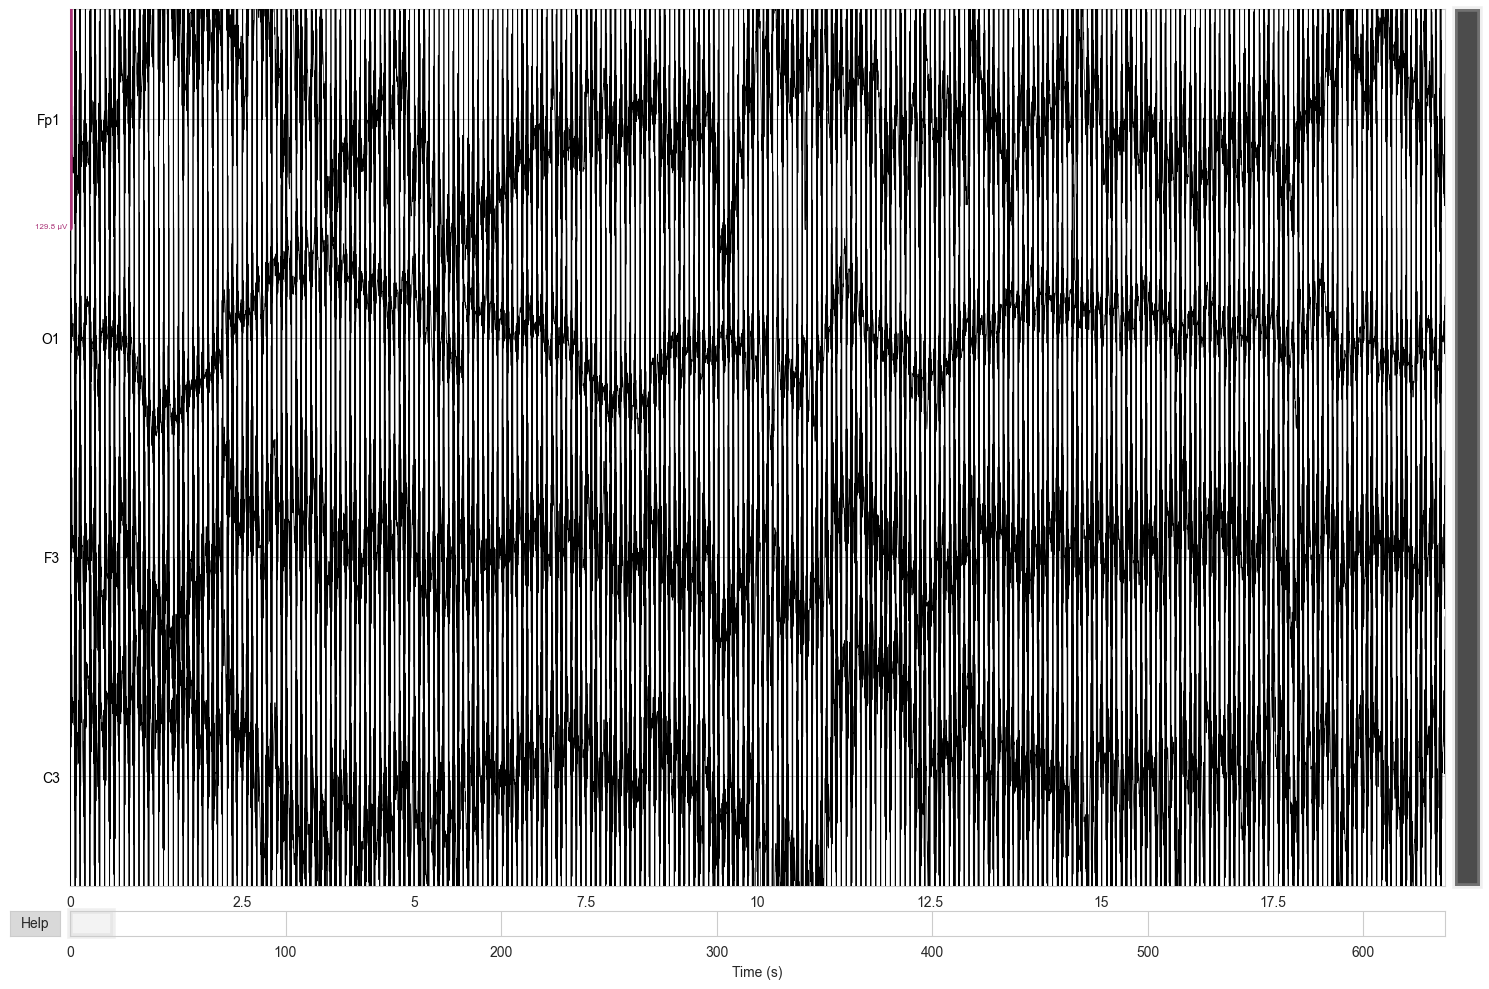

In [32]:
# Plot specific channels for detailed view
fig = plot_timeseries_custom(raw_sleep, start=0, duration=20, picks=['Fp1', 'F3', 'C3', 'O1'],
                             title="Step 1: Selected Channels - Raw Sleep")

### Set Channel Types

In [33]:
print("\n" + "="*80)
print("STEP 2: SETTING CHANNEL TYPES")
print("="*80)


STEP 2: SETTING CHANNEL TYPES


In [34]:
# Set channel types (EEG, EOG, ECG, EMG)
set_custom_channel_types(raw_sleep)
set_custom_channel_types(raw_awake)

✓ Channel types set for 46 channels.
✓ Channel types set for 46 channels.


In [35]:
print("\nChannel types after setting:")
print(f"Sleep - {set([raw_sleep.get_channel_types([ch])[0] for ch in raw_sleep.ch_names])}")
print(f"Awake - {set([raw_awake.get_channel_types([ch])[0] for ch in raw_awake.ch_names])}")


Channel types after setting:
Sleep - {'emg', 'ecg', 'misc', 'eog', 'eeg'}
Awake - {'emg', 'ecg', 'misc', 'eog', 'eeg'}


#### After channel type setup Views

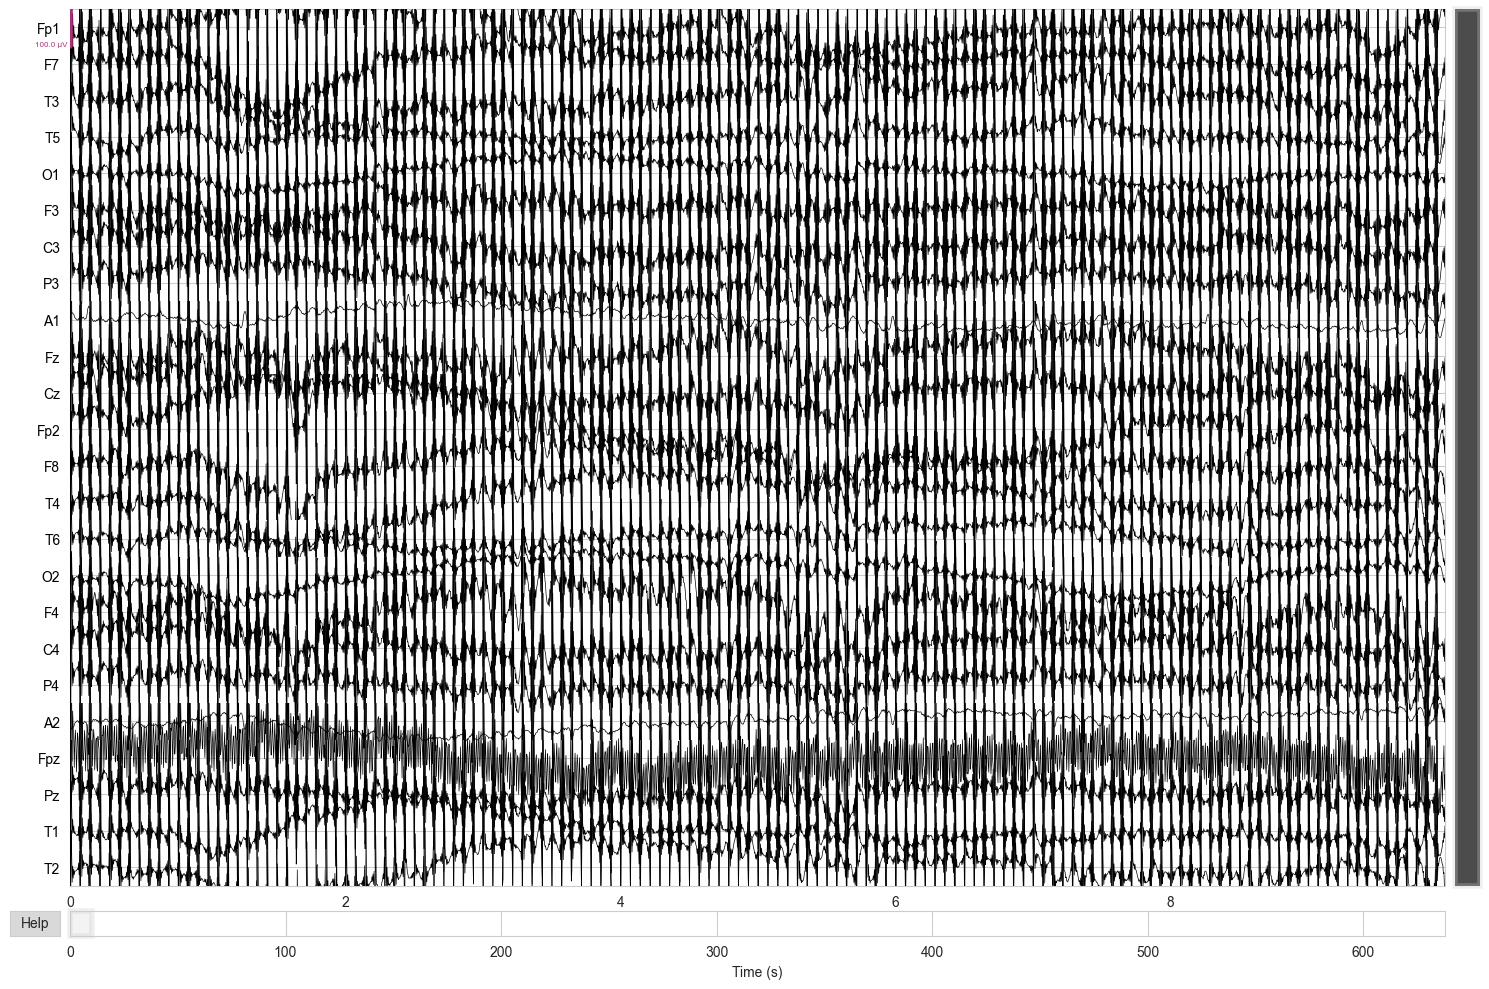

In [36]:
fig = plot_timeseries_custom(raw_sleep, start=0, duration=10,
                             title="Step 2: After Channel Type Setting - Sleep")

### Set Reference

In [37]:
print("\n" + "="*80)
print("STEP 3: SETTING REFERENCE")
print("="*80)


STEP 3: SETTING REFERENCE


In [38]:
# Save copies before referencing for comparison
raw_sleep_before_ref = raw_sleep.copy()
raw_awake_before_ref = raw_awake.copy()

In [39]:
# Set reference (using A1 and A2 mastoid channels)
ref = ['A1', 'A2']
set_reference(raw_sleep, ref_channels=ref)
set_reference(raw_awake, ref_channels=ref)

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
✓ Reference set using channels: ['A1', 'A2']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
✓ Reference set using channels: ['A1', 'A2']


#### Views after set reference

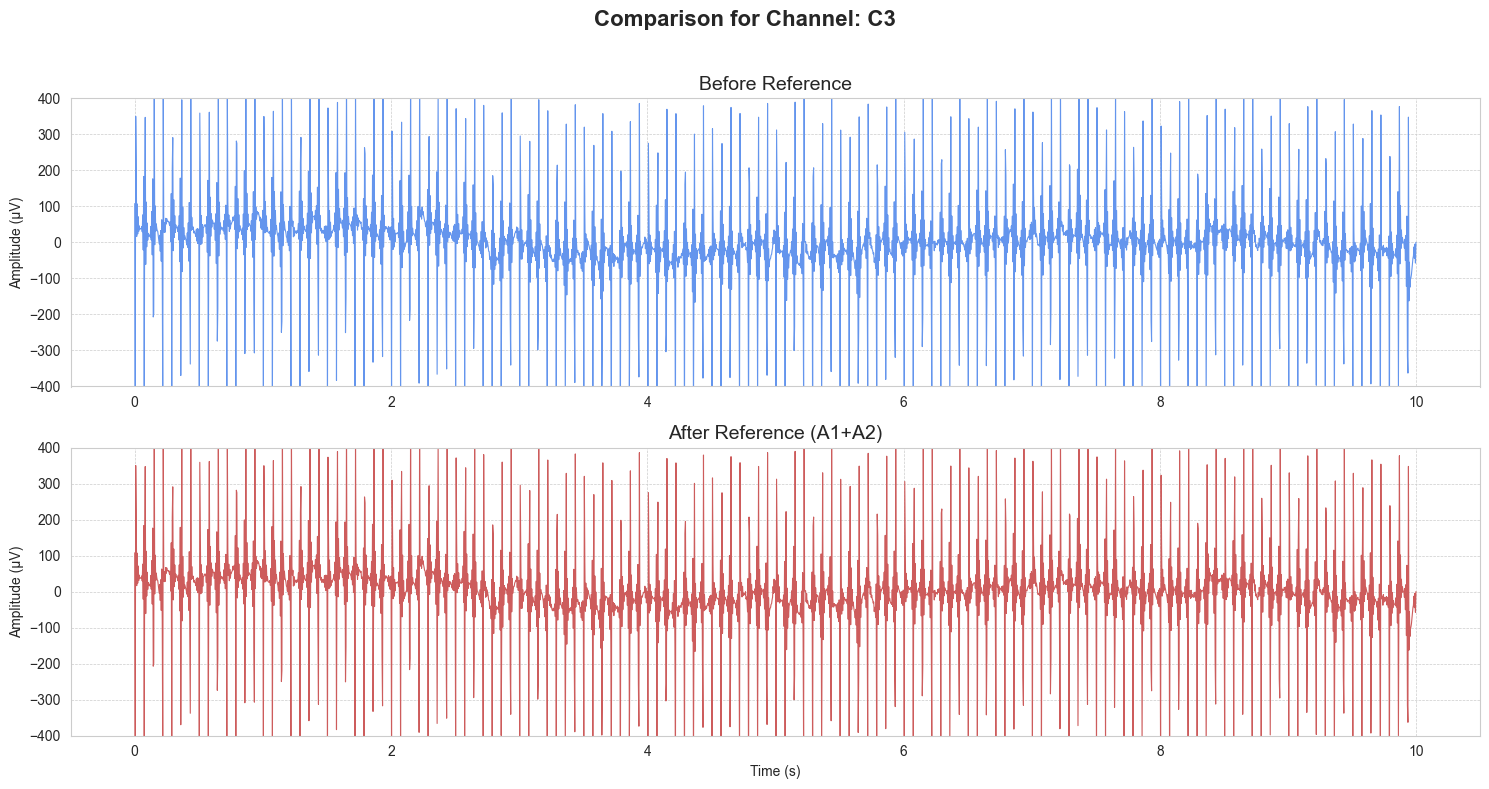

In [40]:
fig = plot_channel_comparison(
    raw1=raw_sleep_before_ref, start1=0,
    raw2=raw_sleep, start2=0,
    channel_name='C3', duration=10.0,
    label1='Before Reference',
    label2='After Reference (A1+A2)',
    figsize=(15, 8),
    y_limits=(-400, 400)
)

### Set Montage

In [41]:
print("\n" + "="*80)
print("STEP 4: SETTING MONTAGE")
print("="*80)


STEP 4: SETTING MONTAGE


In [42]:
set_eeg_montage(raw_sleep)
set_eeg_montage(raw_awake)

✓ Montage 'standard_1020' set successfully!
✓ Montage 'standard_1020' set successfully!


#### View

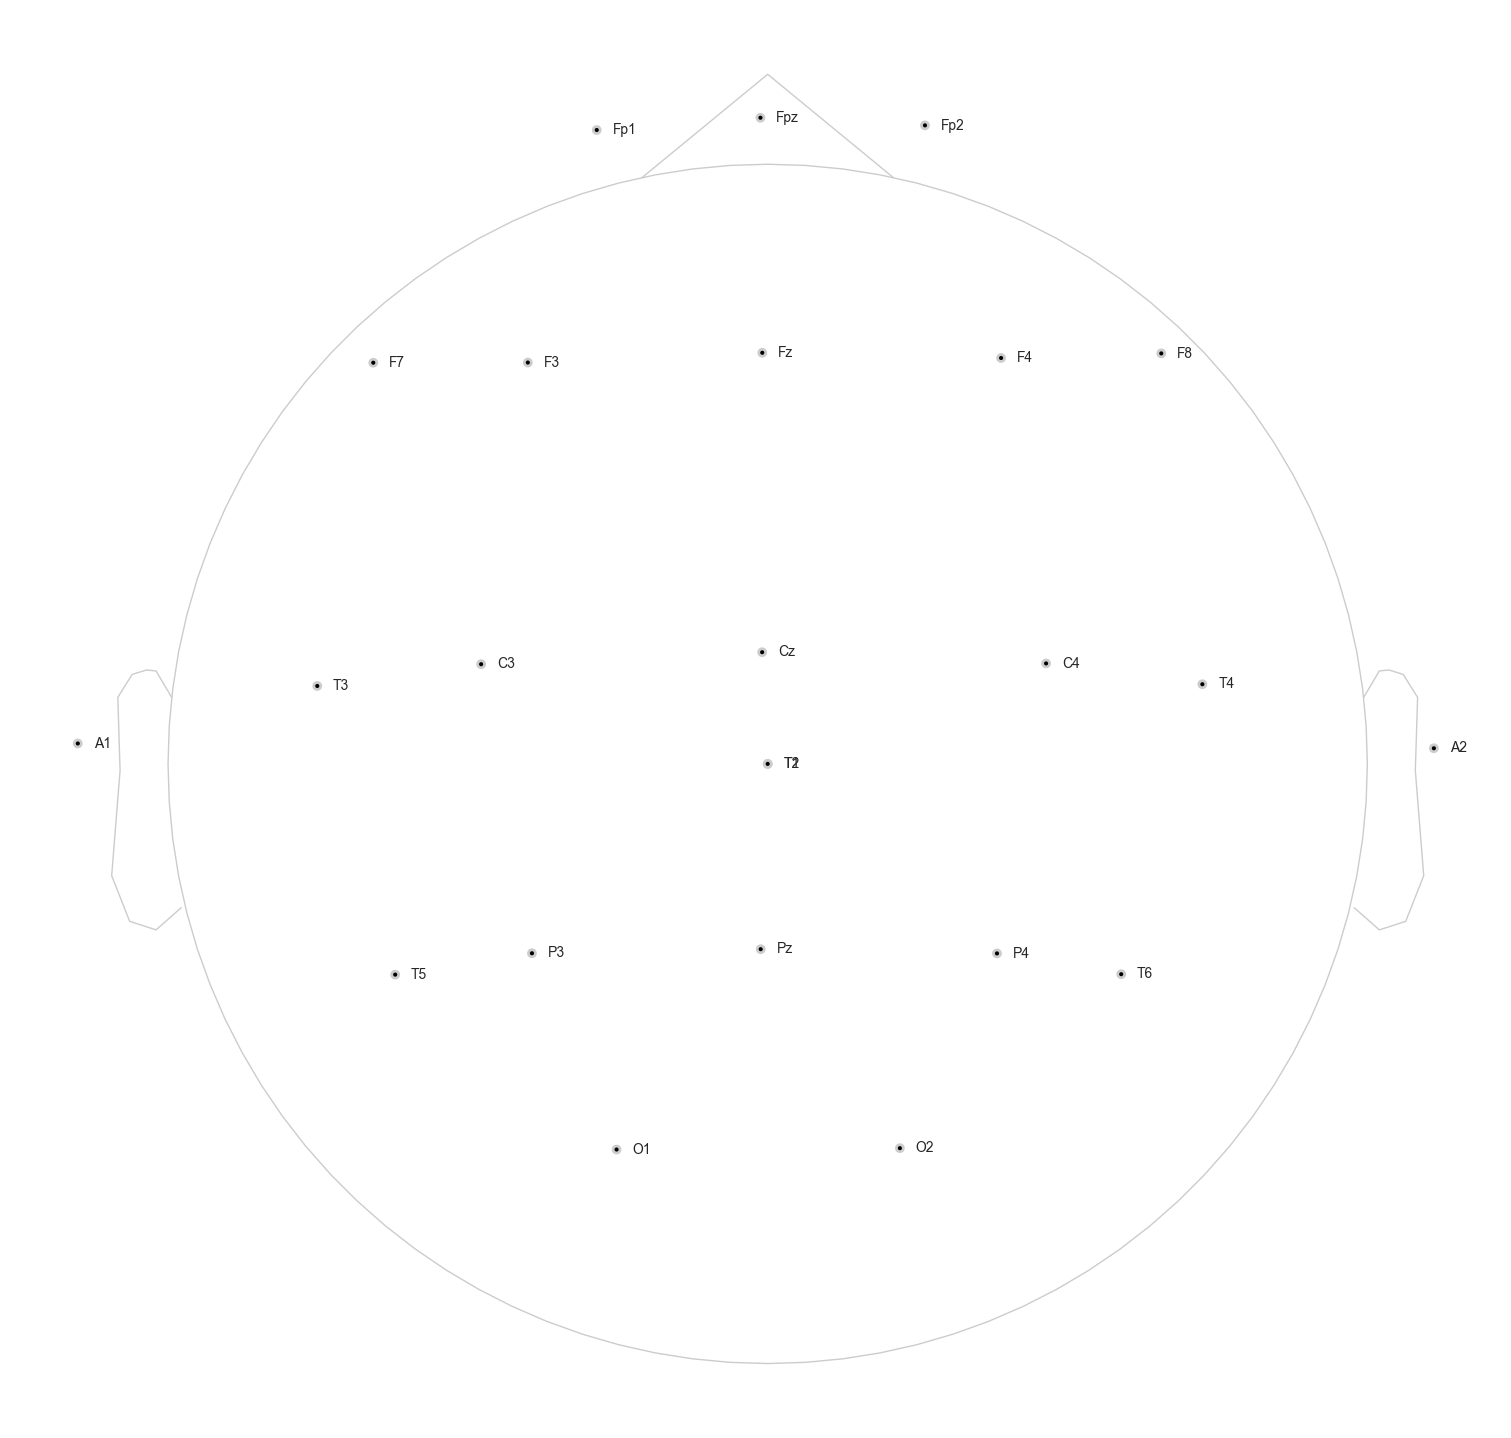

<Figure size 1500x800 with 0 Axes>

In [43]:
fig = raw_sleep.plot_sensors(show_names=True, title='Step 4: Sensor Locations')
plt.savefig('step4_sensor_locations.png', dpi=300, bbox_inches='tight')
plt.show()

### Frequency Filtering

In [44]:
print("\n" + "="*80)
print("STEP 5: APPLYING FREQUENCY FILTERS")
print("="*80)


STEP 5: APPLYING FREQUENCY FILTERS


In [45]:
# Save unfiltered copies for comparison
raw_sleep_unfiltered = raw_sleep.copy()
raw_awake_unfiltered = raw_awake.copy()

In [46]:
# Create filtered copies
raw_sleep_filtered = raw_sleep.copy()
raw_awake_filtered = raw_awake.copy()

In [55]:
# Apply bandpass filter (0.5-40 Hz) and notch filter (60 Hz powerline)
fs = raw_sleep.info['sfreq']
fnyquist = fs / 2 -1
print(f"Sampling Frequency: {fs} Hz, Nyquist Frequency: {fnyquist} Hz")
apply_frequency_filter(raw_sleep_filtered, l_freq=0.5, powerline_freq=60.0, h_freq=40.)
apply_frequency_filter(raw_awake_filtered, l_freq=0.5, powerline_freq=60.0, h_freq=40.)

Sampling Frequency: 256.0 Hz, Nyquist Frequency: 127.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.5

#### Views

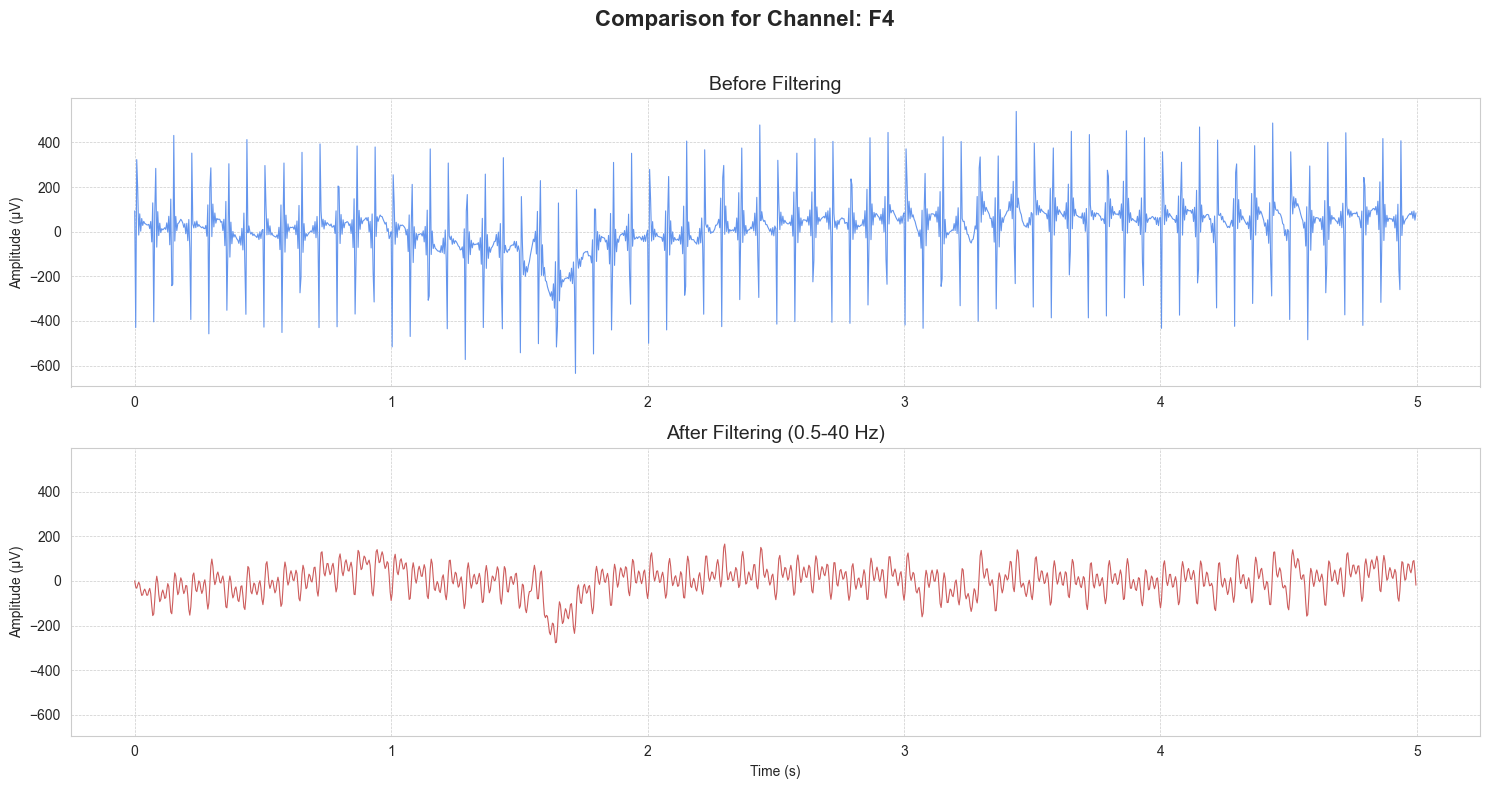

In [56]:
# Time domain comparison
fig = plot_channel_comparison(
    raw1=raw_sleep_unfiltered, start1=0,
    raw2=raw_sleep_filtered, start2=0,
    channel_name='F4', duration=5,
    label1='Before Filtering',
    label2='After Filtering (0.5-40 Hz)',
    figsize=(15, 8)
)

In [65]:
# Calculate PSD for unfiltered data
raw_psd_sleep_freqs, raw_psd_sleep_values = get_psd(raw_sleep_unfiltered, fmin=0.5, fmax=127)
raw_psd_awake_freqs, raw_psd_awake_values = get_psd(raw_awake_unfiltered, fmin=0.5, fmax=127)


Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


In [66]:
# Calculate PSD for filtered data
filt_psd_sleep_freqs, filt_psd_sleep_values = get_psd(raw_sleep_filtered, fmin=0.5, fmax=127)
filt_psd_awake_freqs, filt_psd_awake_values = get_psd(raw_awake_filtered, fmin=0.5, fmax=127)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


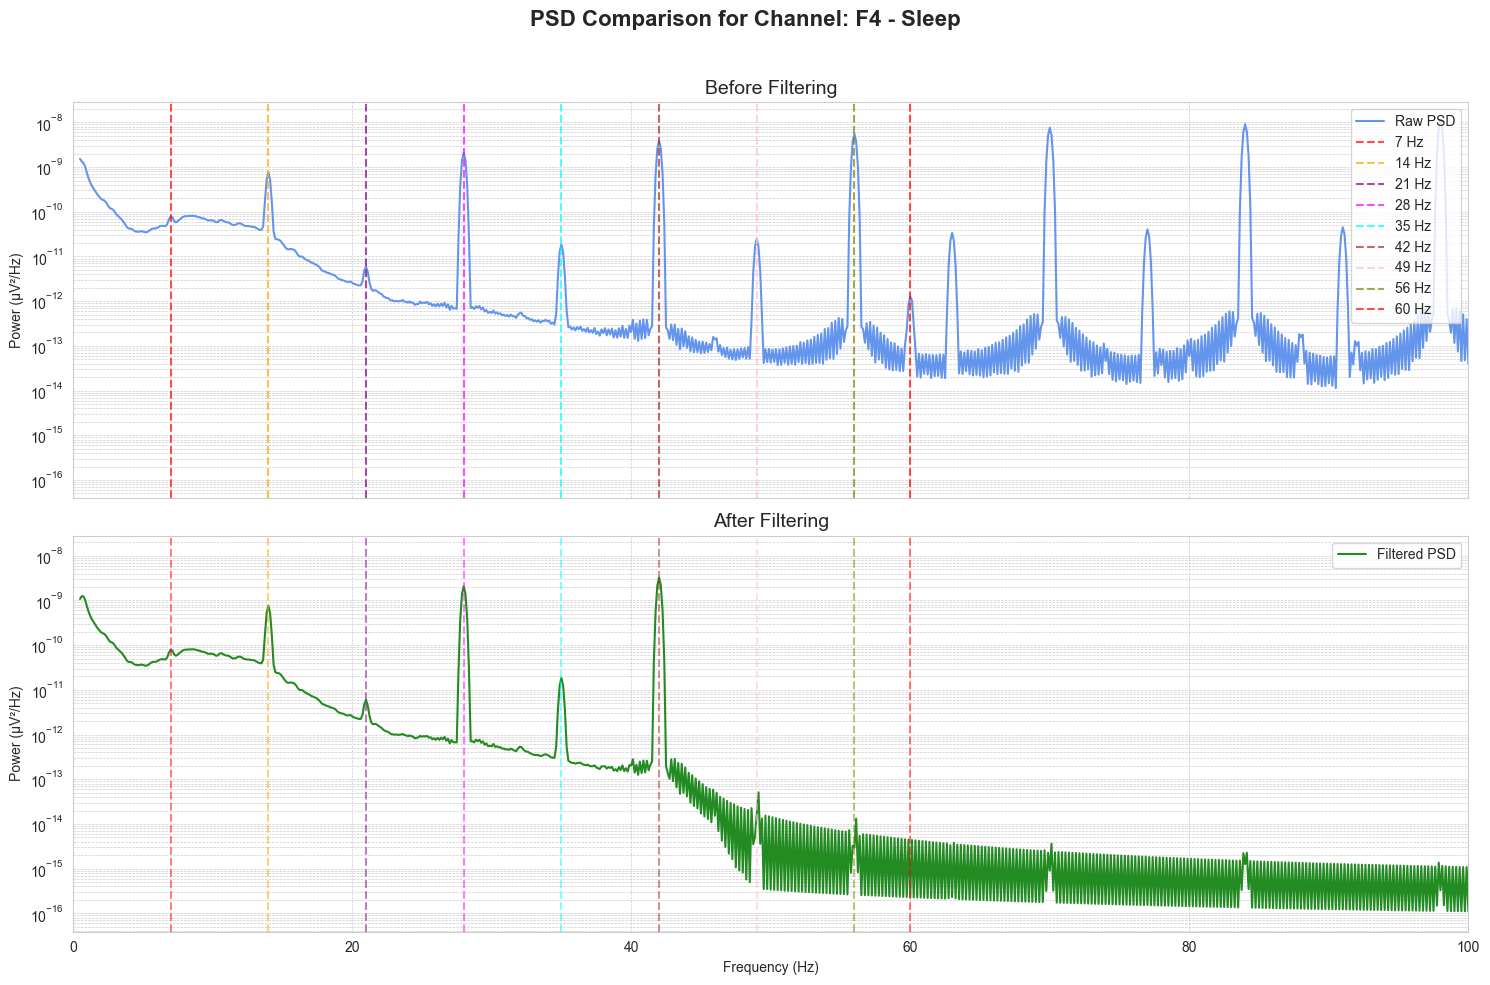

In [67]:
fig = plot_psd_comparison(
    freqs_raw=raw_psd_sleep_freqs,
    psd_raw=raw_psd_sleep_values[raw_sleep.ch_names.index('F4')],
    freqs_filt=filt_psd_sleep_freqs,
    psd_filt=filt_psd_sleep_values[raw_sleep.ch_names.index('F4')],
    channel_name='F4 - Sleep',
    artifact_freqs=[7, 14, 21, 28, 35, 42, 49, 56, 60],  # DBS harmonics + powerline
    figsize=(15, 10),
    fmin=0.0,
    fmax=100.0
)

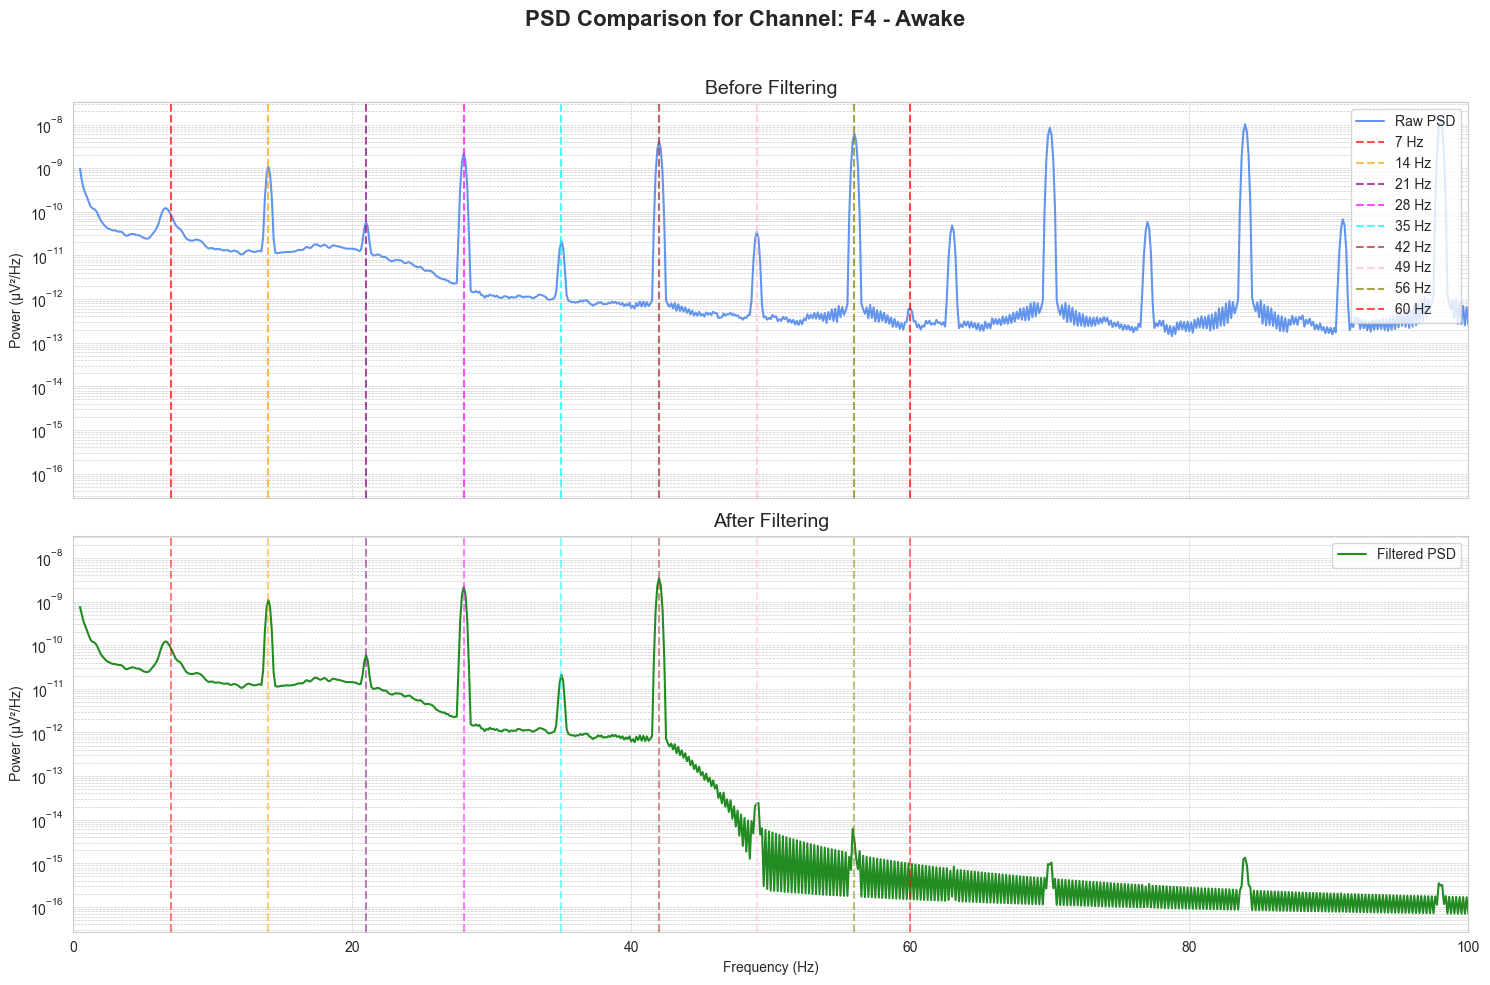

In [42]:
# PSD comparison - Awake
fig = plot_psd_comparison(
    freqs_raw=raw_psd_awake_freqs,
    psd_raw=raw_psd_awake_values[raw_awake.ch_names.index('F4')],
    freqs_filt=filt_psd_awake_freqs,
    psd_filt=filt_psd_awake_values[raw_awake.ch_names.index('F4')],
    channel_name='F4 - Awake',
    artifact_freqs=[7, 14, 21, 28, 35, 42, 49, 56, 60],
    figsize=(15, 10),
    fmin=0.0,
    fmax=100.0
)

### DBS artifact removal

Notching frequencies: [ 7. 14. 21. 28. 35.] Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)



✓ Removed DBS harmonics up to 5 harmonics at 7 Hz intervals.


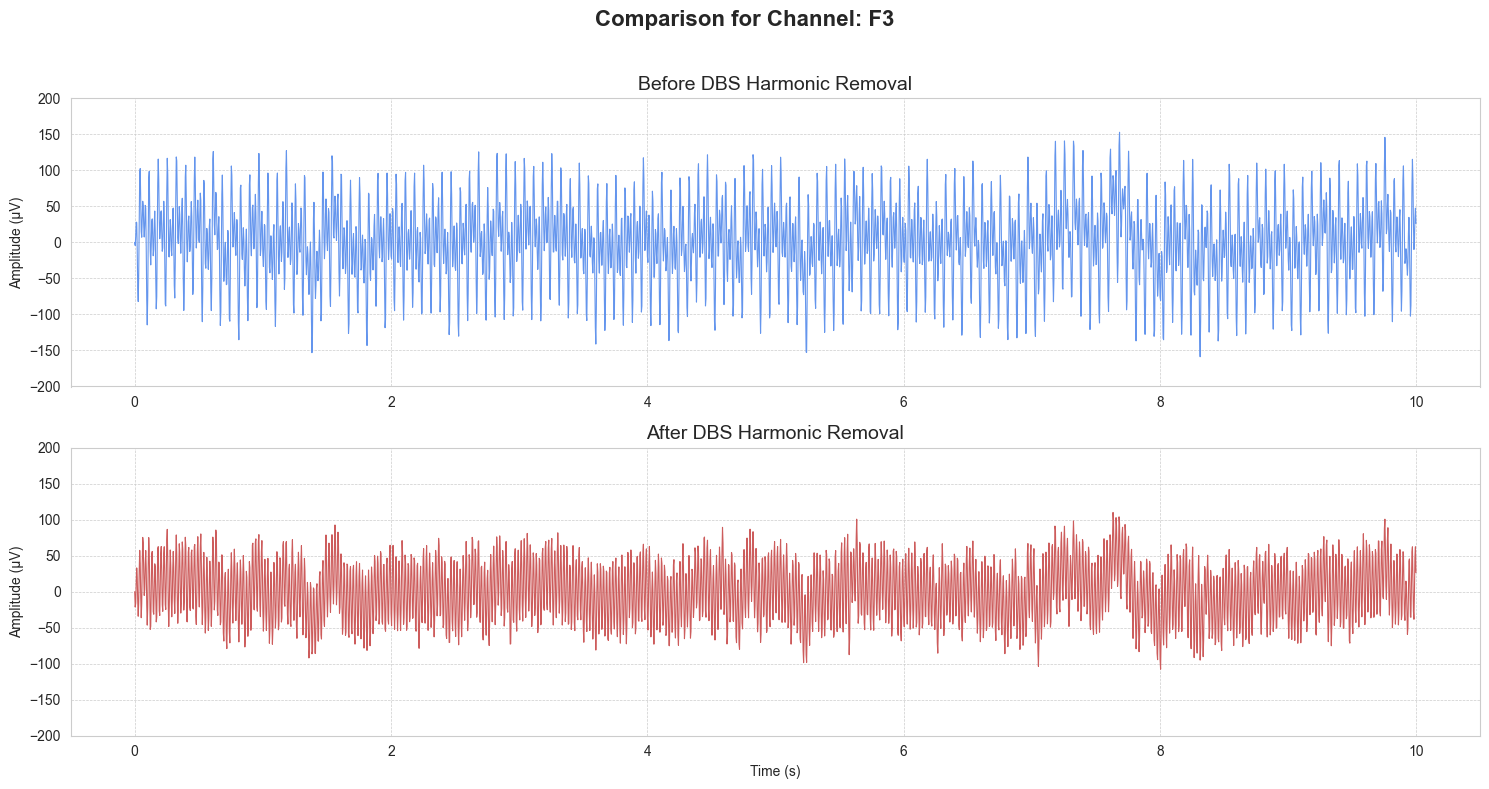

In [71]:
raw_awake_filtered_dbs = raw_awake_filtered.copy()
DBS_harmonics_removal(raw_awake_filtered_dbs, dbs_freq=7, n_harmonics=5, h_freq=40.0)
fig = plot_channel_comparison(
    raw1=raw_awake_filtered, start1=0,
    raw2=raw_awake_filtered_dbs, start2=0,
    channel_name='F3', duration=10.0,
    label1='Before DBS Harmonic Removal',
    label2='After DBS Harmonic Removal',
    figsize=(15, 8),
    y_limits=(-200, 200)
)

Notching frequencies: [ 7. 14. 21. 28. 35.] Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

✓ Removed DBS harmonics up to 5 harmonics at 7 Hz intervals.


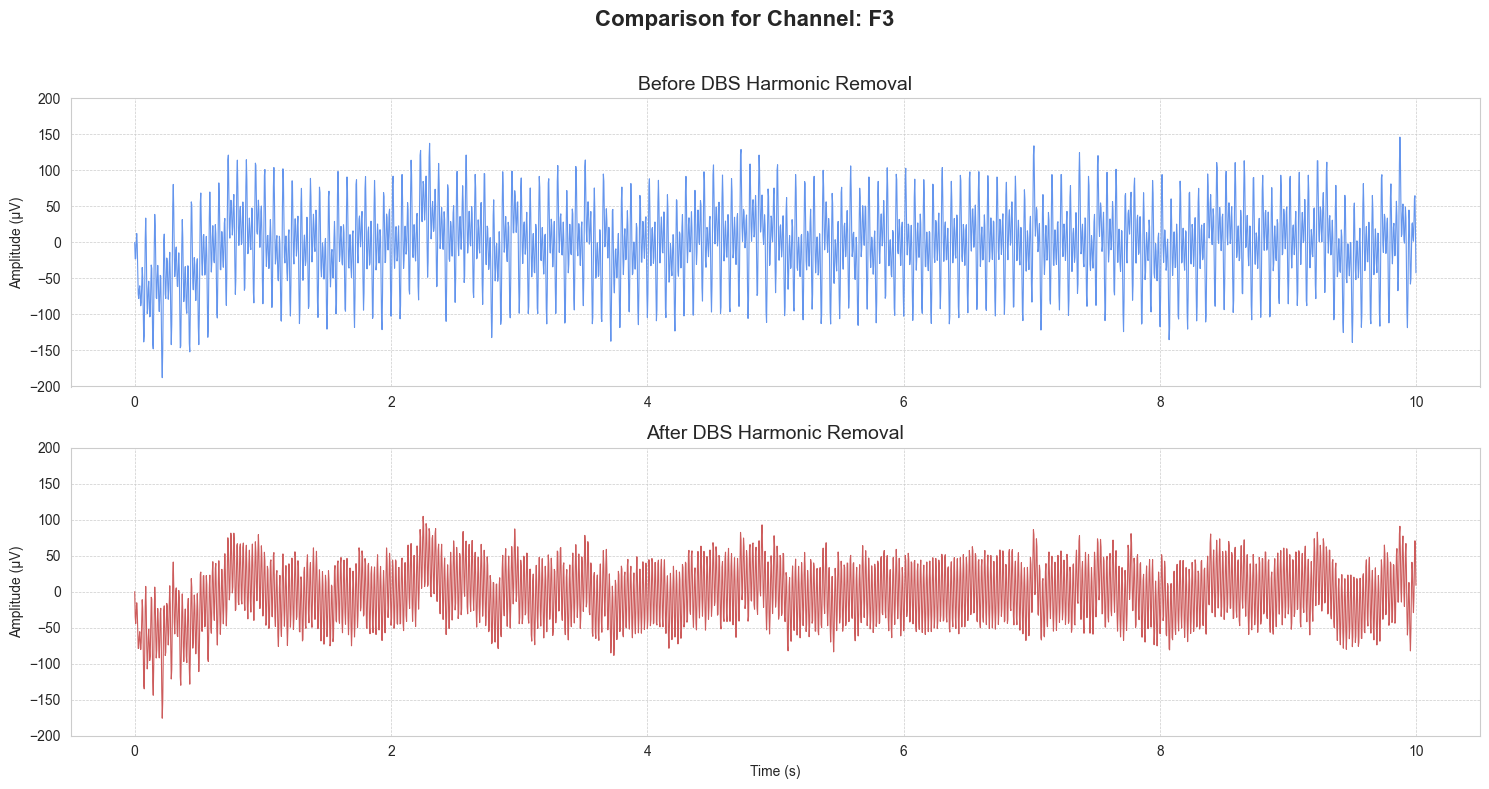

In [72]:
raw_sleep_filtered_dbs = raw_sleep_filtered.copy()
DBS_harmonics_removal(raw_sleep_filtered_dbs, dbs_freq=7, n_harmonics=5, h_freq=40.0)
fig = plot_channel_comparison(
    raw1=raw_sleep_filtered, start1=0,
    raw2=raw_sleep_filtered_dbs, start2=0,
    channel_name='F3', duration=10.0,
    label1='Before DBS Harmonic Removal',
    label2='After DBS Harmonic Removal',
    figsize=(15, 8),
    y_limits=(-200, 200)
)

In [73]:
# Calculate PSD for filtered data
filt_psd_sleep_dbs_freqs, filt_psd_sleep_dbs_values = get_psd(raw_sleep_filtered_dbs, fmin=0.5, fmax=127)
filt_psd_awake_dbs_freqs, filt_psd_awake_dbs_values = get_psd(raw_awake_filtered_dbs, fmin=0.5, fmax=127)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


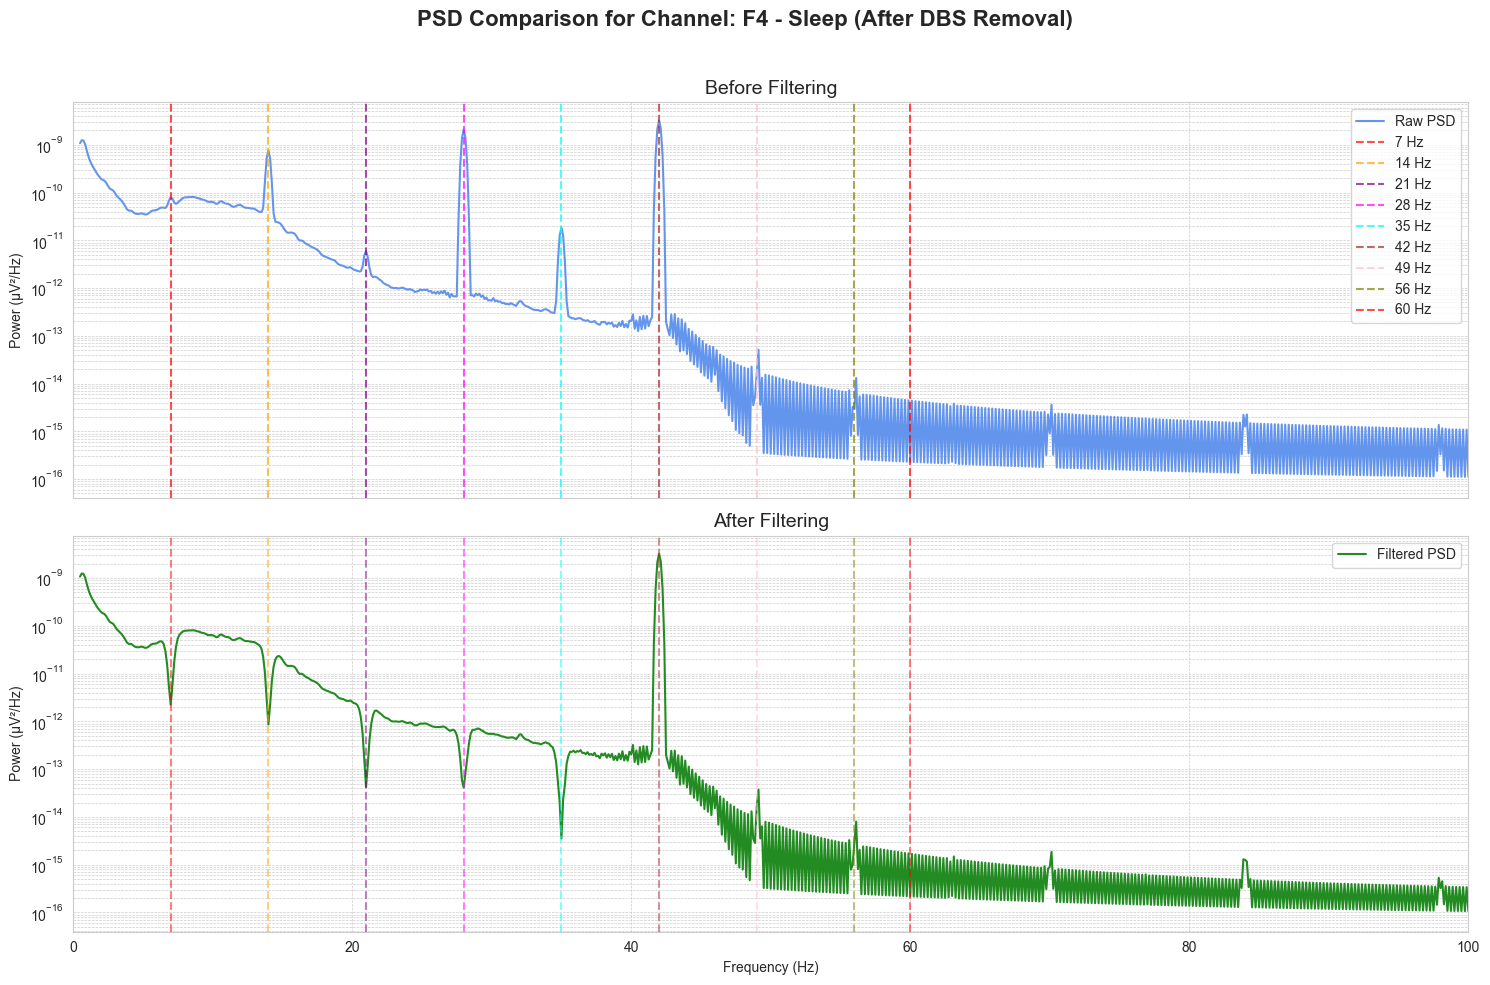

In [74]:
fig = plot_psd_comparison(
    freqs_raw=filt_psd_sleep_freqs,
    psd_raw=filt_psd_sleep_values[raw_sleep.ch_names.index('F4')],
    freqs_filt=filt_psd_sleep_dbs_freqs,
    psd_filt=filt_psd_sleep_dbs_values[raw_sleep.ch_names.index('F4')],
    channel_name='F4 - Sleep (After DBS Removal)',
    artifact_freqs=[7, 14, 21, 28, 35, 42, 49, 56, 60],
    figsize=(15, 10),
    fmin=0.0,
    fmax=100.0
)

In [75]:
raw_awake_filtered = raw_awake_filtered_dbs.copy()
raw_sleep_filtered = raw_sleep_filtered_dbs.copy()

### Band Power Analysis - Before Artifact Removal

In [76]:
# Get EEG channels only
eeg_channels_sleep = [ch for ch in raw_sleep_filtered.ch_names 
                      if raw_sleep_filtered.get_channel_types([ch])[0] == 'eeg']
eeg_channels_awake = [ch for ch in raw_awake_filtered.ch_names 
                      if raw_awake_filtered.get_channel_types([ch])[0] == 'eeg']

In [77]:
print(f"EEG channels: {len(eeg_channels_sleep)}")

EEG channels: 24


In [78]:
# Calculate band powers - Sleep
df_band_powers_sleep = calculate_band_powers(
    psd=filt_psd_sleep_values,
    freqs=filt_psd_sleep_freqs,
    ch_names=eeg_channels_sleep
)

print("Band powers for Sleep (first 5 channels):")
print(df_band_powers_sleep.head())


Band powers for Sleep (first 5 channels):
         Delta (0.5-4 Hz)  Theta (4-8 Hz)  Alpha (8-13 Hz)  Beta (13-30 Hz)  \
Channel                                                                       
Fp1          3.892488e-10    1.367879e-10     7.872126e-11     6.951617e-10   
F7           1.771744e-10    6.549871e-11     4.694623e-11     6.530534e-10   
T3           3.450935e-10    1.717909e-10     1.309459e-10     6.031510e-10   
T5           1.808153e-10    8.011900e-11     5.780818e-11     2.466726e-10   
O1           1.188410e-10    3.292929e-11     3.618265e-11     1.665697e-10   

         Gamma (30-40 Hz)  
Channel                    
Fp1          3.157809e-12  
F7           1.381734e-12  
T3           2.007908e-12  
T5           8.717830e-13  
O1           6.776440e-13  


In [79]:
# Calculate band powers - Awake
df_band_powers_awake = calculate_band_powers(
    psd=filt_psd_awake_values,
    freqs=filt_psd_awake_freqs,
    ch_names=eeg_channels_awake
)

print("Band powers for Awake (first 5 channels):")
print(df_band_powers_awake.head())

Band powers for Awake (first 5 channels):
         Delta (0.5-4 Hz)  Theta (4-8 Hz)  Alpha (8-13 Hz)  Beta (13-30 Hz)  \
Channel                                                                       
Fp1          8.903639e-10    1.511649e-10     6.812008e-11     8.717756e-10   
F7           3.292747e-10    5.869742e-11     2.913209e-11     8.103850e-10   
T3           3.496548e-10    1.991237e-10     7.184376e-11     7.700897e-10   
T5           2.140732e-10    6.806647e-11     2.932236e-11     4.091560e-10   
O1           2.347659e-10    2.743943e-11     2.195840e-11     3.884779e-10   

         Gamma (30-40 Hz)  
Channel                    
Fp1          2.906534e-11  
F7           8.018082e-12  
T3           7.279884e-12  
T5           3.577692e-12  
O1           4.400689e-12  


In [80]:
# Topomaps - Sleep
band_powers_dict_sleep = {band: df_band_powers_sleep[band].values 
                          for band in df_band_powers_sleep.columns}

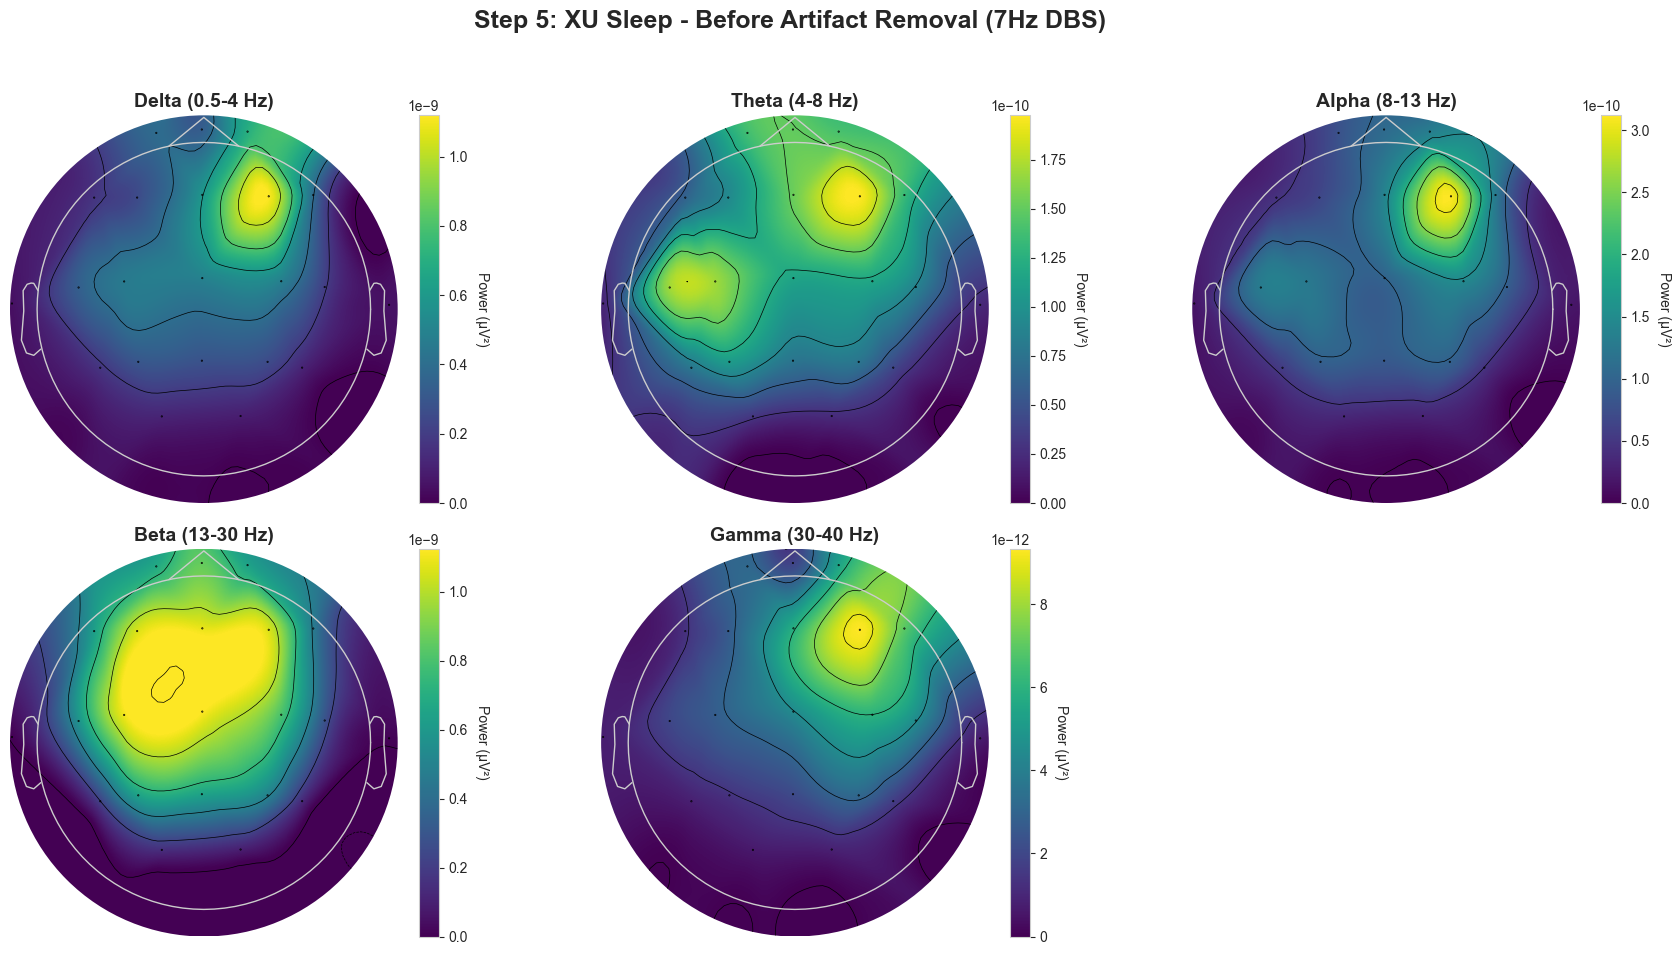

In [81]:
fig = plot_band_power_topomaps(
    raw_object=raw_sleep_filtered,
    band_powers=band_powers_dict_sleep,
    suptitle=f'Step 5: {patient} Sleep - Before Artifact Removal ({dbs_freq}Hz DBS)'
)

In [82]:
band_powers_dict_awake = {band: df_band_powers_awake[band].values 
                          for band in df_band_powers_awake.columns}


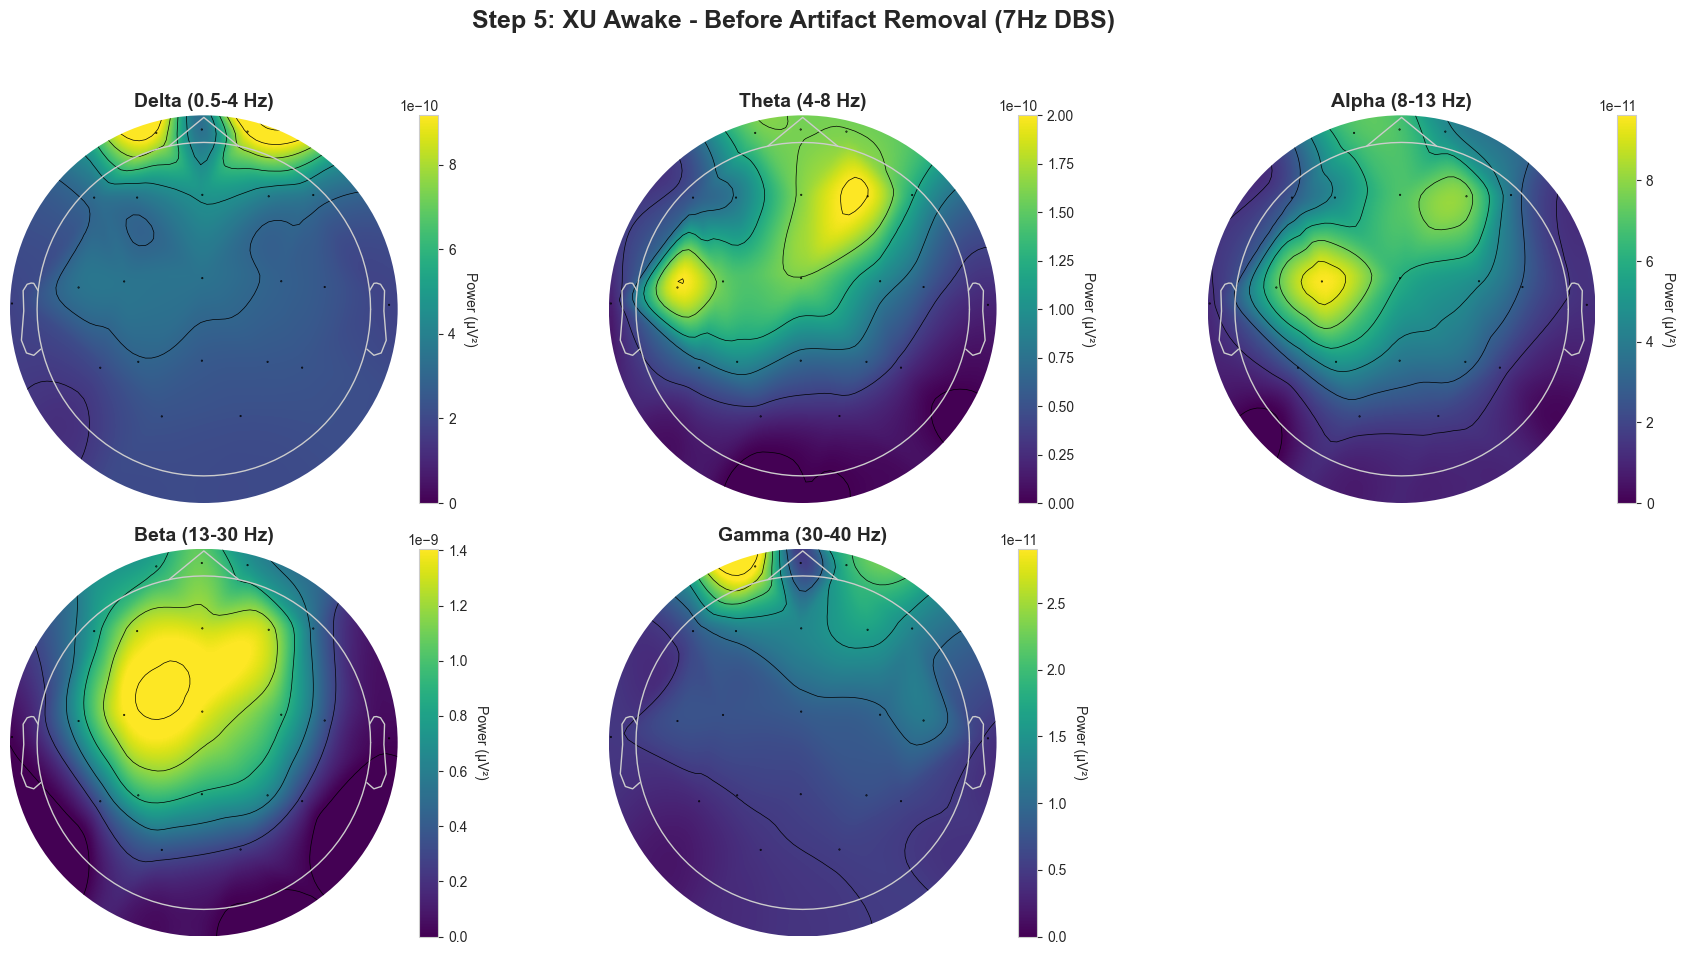

In [83]:
fig = plot_band_power_topomaps(
    raw_object=raw_awake_filtered,
    band_powers=band_powers_dict_awake,
    suptitle=f'Step 5: {patient} Awake - Before Artifact Removal ({dbs_freq}Hz DBS)'
)

### Bad Channel Detection & Interpolation

In [84]:
print("\n" + "="*80)
print("STEP 6: BAD CHANNEL DETECTION & INTERPOLATION")
print("="*80)


STEP 6: BAD CHANNEL DETECTION & INTERPOLATION


In [85]:
# Detect bad channels automatically
detected_bads_sleep = detect_bad_channels_by_variance(raw_sleep_filtered, z_threshold=3.0)
detected_bads_awake = detect_bad_channels_by_variance(raw_awake_filtered, z_threshold=3.0)

In [86]:
print(f"Bad channels detected in Sleep: {detected_bads_sleep}")
print(f"Bad channels detected in Awake: {detected_bads_awake}")

Bad channels detected in Sleep: []
Bad channels detected in Awake: []


In [87]:
# Save before interpolation for comparison
raw_sleep_before_interp = raw_sleep_filtered.copy()
raw_awake_before_interp = raw_awake_filtered.copy()

In [88]:
# Mark and interpolate bad channels
raw_sleep_filtered.info['bads'].extend(detected_bads_sleep)
raw_awake_filtered.info['bads'].extend(detected_bads_awake)

In [89]:
if len(detected_bads_sleep) > 0:
    raw_sleep_filtered.interpolate_bads(reset_bads=True)
    print(f"✓ Interpolated {len(detected_bads_sleep)} bad channels in Sleep")

if len(detected_bads_awake) > 0:
    raw_awake_filtered.interpolate_bads(reset_bads=True)
    print(f"✓ Interpolated {len(detected_bads_awake)} bad channels in Awake")

#### Views

In [90]:
# If bad channels were found, show comparison
if len(detected_bads_sleep) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    raw_sleep_before_interp.plot_psd_topomap(bands=[(8, 12, 'Alpha')], axes=axes[0], show=False)
    axes[0].set_title('Step 6a: Before Interpolation')
    raw_sleep_filtered.plot_psd_topomap(bands=[(8, 12, 'Alpha')], axes=axes[1], show=False)
    axes[1].set_title('Step 6b: After Interpolation')
    plt.tight_layout()
    plt.show()

### Prepare Data for ICA

In [91]:
print("\n" + "="*80)
print("STEP 7: PREPARING DATA FOR ICA")
print("="*80)


STEP 7: PREPARING DATA FOR ICA


In [92]:
# Create copies for ICA (we'll drop non-standard channels and apply high-pass filter)
raw_awake_for_ica = raw_awake_filtered.copy()
raw_sleep_for_ica = raw_sleep_filtered.copy()

In [93]:
# Drop extended channels that might not be needed
channels_to_drop = [ch for ch in ['T1', 'T2', 'Fpz'] if ch in raw_awake_for_ica.ch_names]
if channels_to_drop:
    raw_awake_for_ica.drop_channels(channels_to_drop)
    raw_sleep_for_ica.drop_channels(channels_to_drop)
    print(f"✓ Dropped channels: {channels_to_drop}")

✓ Dropped channels: ['T1', 'T2', 'Fpz']


In [94]:
# Apply 1 Hz high-pass filter for ICA (recommended to remove slow drifts)
print("Applying 1 Hz high-pass filter for ICA...")
raw_awake_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')
raw_sleep_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

Applying 1 Hz high-pass filter for ICA...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)



<RawEDF | XUSLEEP7.EDF, 43 x 163328 (638.0 s), ~53.6 MiB, data loaded>

In [95]:
print(f"✓ Data prepared for ICA")
print(f"  Sleep channels: {len(raw_sleep_for_ica.ch_names)}")
print(f"  Awake channels: {len(raw_awake_for_ica.ch_names)}")

✓ Data prepared for ICA
  Sleep channels: 43
  Awake channels: 43


### Create EOG/ECG Epochs

In [96]:
print("\n" + "="*80)
print("STEP 8: CREATING EOG/ECG EPOCHS")
print("="*80)


STEP 8: CREATING EOG/ECG EPOCHS


In [117]:
# Create EOG epochs (blinks) - AWAKE
print("Creating EOG epochs from awake data...")
try:
    eog_epochs = mne.preprocessing.create_eog_epochs(raw_awake_for_ica, ch_name=['Fp1', 'Fp2'], reject_by_annotation=True)
    eog_evoked = eog_epochs.average()
    eog_evoked.apply_baseline(baseline=(None, -0.2))
    print(f"✓ Created {len(eog_epochs)} EOG epochs")
except Exception as e:
    print(f"Note: Could not create EOG epochs - {e}")
    eog_evoked = None

Creating EOG epochs from awake data...
Using EOG channels: Fp1, Fp2
EOG channel index for this subject is: [ 0 11]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 114 significant peaks
Number of EOG events detected: 114
Not setting metadata
114 matching events found
No baseline correction applied
Using data from preloaded Raw for 114 events and 257 original time points ...
1 

In [118]:
# Create ECG epochs (heartbeats) - AWAKE
print("Creating ECG epochs from awake data...")
try:
    ecg_epochs = mne.preprocessing.create_ecg_epochs(raw_awake_for_ica)
    ecg_evoked = ecg_epochs.average()
    ecg_evoked.apply_baseline(baseline=(None, -0.2))
    print(f"✓ Created {len(ecg_epochs)} ECG epochs")
except Exception as e:
    print(f"Note: Could not create ECG epochs - {e}")
    ecg_evoked = None

Creating ECG epochs from awake data...
Using channel EKGL to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 2560 samples (10.000 s)

Number of ECG events detected : 755 (average pulse 79.75352112676056 / min.)
Not setting metadata
755 matching events found
No baseline correction applied
Using data from preloaded Raw for 755 events and 257 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
✓ Created 755 ECG epochs


#### Views

No projector specified for this dataset. Please consider the method self.add_proj.


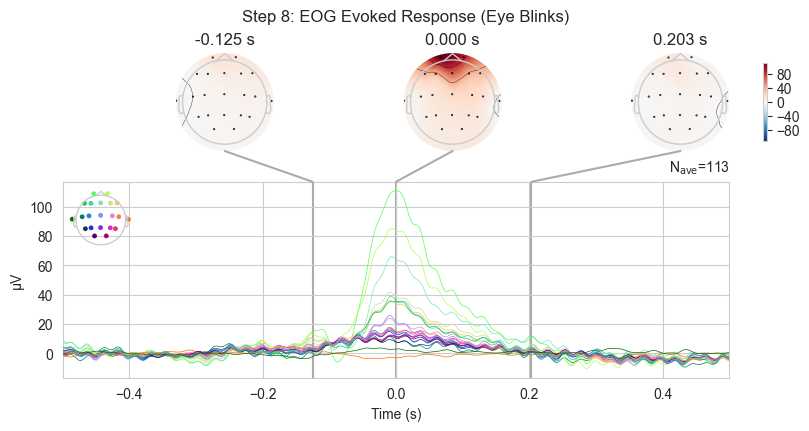

In [119]:
# Plot EOG evoked (eye blink artifact)
if eog_evoked is not None:
    fig = eog_evoked.plot_joint(title='Step 8: EOG Evoked Response (Eye Blinks)')
    plt.show()

No projector specified for this dataset. Please consider the method self.add_proj.


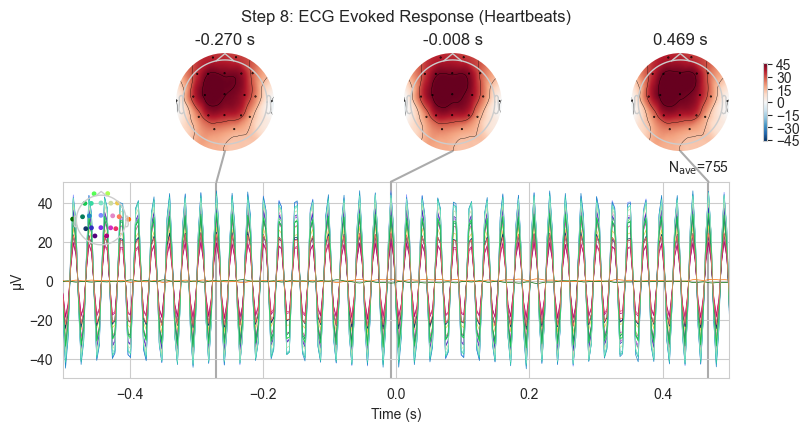

In [120]:
# Plot ECG evoked (heartbeat artifact)
if ecg_evoked is not None:
    fig = ecg_evoked.plot_joint(title='Step 8: ECG Evoked Response (Heartbeats)')
    plt.show()

## Fit ICA - AWAKE DATA

In [121]:
print("\n" + "="*80)
print("STEP 9: FITTING ICA ON AWAKE DATA")
print("="*80)


STEP 9: FITTING ICA ON AWAKE DATA


In [122]:
n_components = 15
ica_awake = ICA(n_components=n_components, random_state=97, max_iter='auto', method='fastica')

In [123]:
print(f"Fitting ICA with {n_components} components...")
ica_awake.fit(raw_awake_for_ica)
print("✓ ICA fitting completed!")

Fitting ICA with 15 components...
Fitting ICA to data using 21 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.4s.
✓ ICA fitting completed!


In [124]:
# Check explained variance
explained_var_ratio = ica_awake.get_explained_variance_ratio(
    raw_awake_for_ica, components=[0], ch_type="eeg"
)
ratio_percent = round(100 * explained_var_ratio["eeg"])
print(f"Variance explained by first component: {ratio_percent}%")

Variance explained by first component: 36%


#### Views

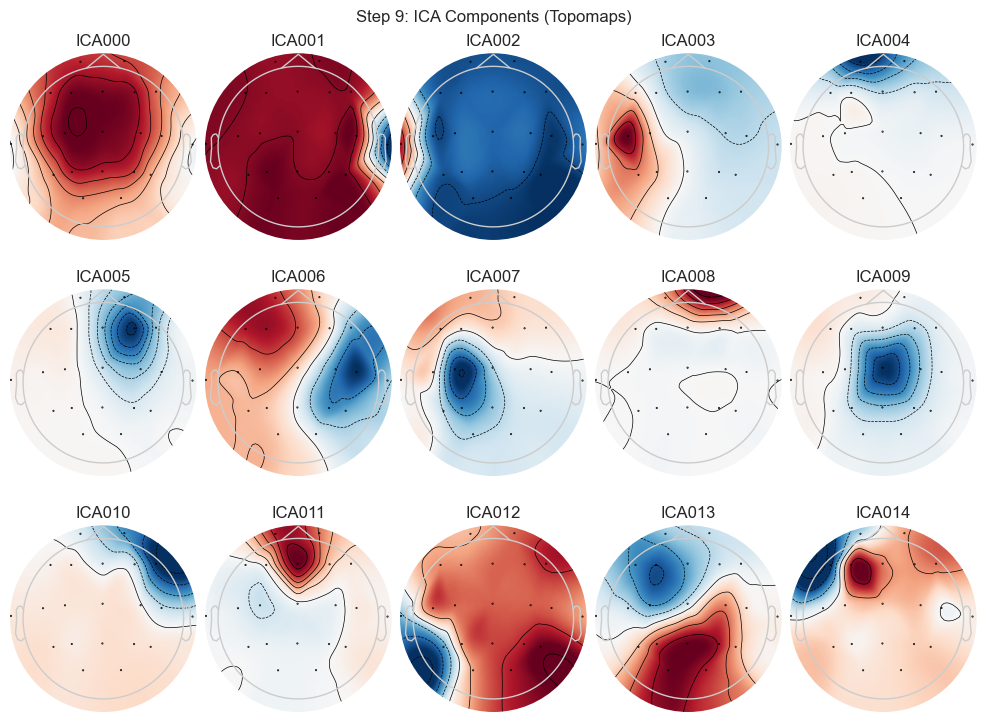

In [125]:
# Plot all ICA components as topomaps
fig = ica_awake.plot_components(title='Step 9: ICA Components (Topomaps)')
plt.show()

Creating RawArray with float64 data, n_channels=19, n_times=145408
    Range : 0 ... 145407 =      0.000 ...   567.996 secs
Ready.


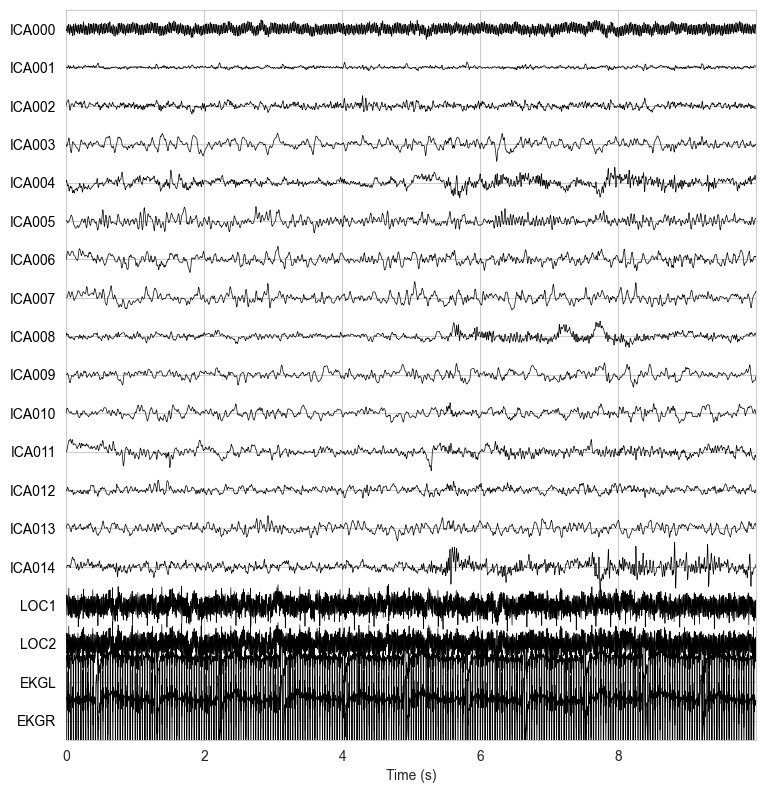

In [126]:
# Plot ICA sources (time series)
fig = ica_awake.plot_sources(raw_awake_for_ica, start=0, stop=10, 
                             title='Step 9: ICA Source Time Series',
                             show_scrollbars=False)
plt.show()

#### Identify and Mark Artifact Components

In [127]:
print("\n" + "="*80)
print("STEP 10: IDENTIFYING ARTIFACT COMPONENTS")
print("="*80)



STEP 10: IDENTIFYING ARTIFACT COMPONENTS


In [128]:
# Find EOG components automatically
ica_awake.exclude = []
eog_indices, eog_scores = ica_awake.find_bads_eog(raw_awake_for_ica, ch_name=['LOC1', 'LOC2'])
ica_awake.exclude = eog_indices

Using EOG channels: LOC1, LOC2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.2

In [129]:
print(f"EOG components identified: {eog_indices}")
print(f"Components marked for exclusion: {ica_awake.exclude}")

EOG components identified: []
Components marked for exclusion: []


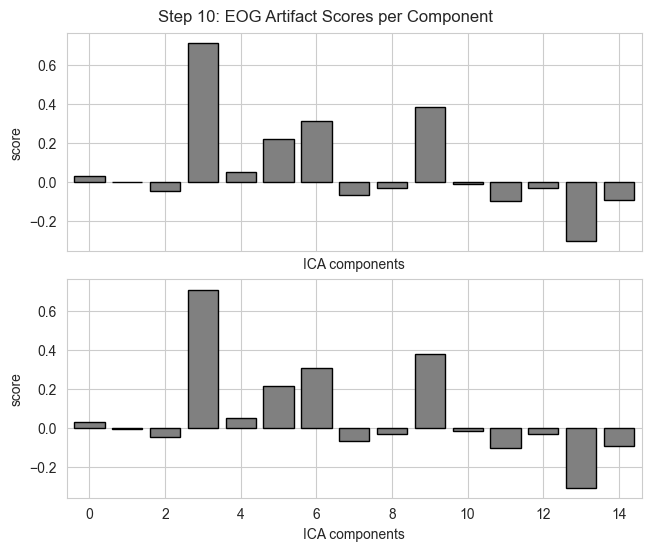

In [130]:
# Plot EOG scores for all components
fig = ica_awake.plot_scores(eog_scores, title='Step 10: EOG Artifact Scores per Component')
plt.show()

In [131]:
# Plot properties of identified EOG components
if len(eog_indices) > 0:
    print(f"Plotting properties of {len(eog_indices)} EOG components...")
    fig = ica_awake.plot_properties(raw_awake_for_ica, picks=eog_indices, psd_args={'fmax': 50})
    plt.show()
else:
    print("No EOG components found automatically.")

No EOG components found automatically.


In [132]:
# Plot overlay showing effect of removing EOG components
if len(eog_indices) > 0:
    fig = ica_awake.plot_overlay(raw_awake_for_ica, exclude=eog_indices, picks='eeg',
                                 title='Step 10: Effect of Removing EOG Components')
    plt.show()
